In [1]:
! pip install clearml roboflow rich ultralytics onnxruntime  python-dotenv certifi


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 78.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 184.0/184.0 kB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 19.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 70.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 102.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 94.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 127.7 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11


In [2]:
"""
ClearML helpers shared across all training scripts.
Reads credentials from environment / ~/.clearml.conf.
"""

import os
from typing import Any

from clearml import Dataset, Task
from dotenv import load_dotenv

load_dotenv("env")


def init_task(
    project: str,
    name: str,
    task_type: Task.TaskTypes = Task.TaskTypes.training,
    tags: list[str] | None = None,
    config: dict[str, Any] | None = None,
    reuse_last_task_id: bool = False,
) -> Task:
    """
    Initialise a ClearML task and connect hyperparameters.

    Args:
        project:  ClearML project name, e.g. "MedVision/MRI-Segmentation"
        name:     Task name, e.g. "train-yolo-v1"
        task_type: training | testing | inference | ...
        tags:     Optional list of tags shown in the UI
        config:   Dict of hyperparameters to log (auto-connected)
        reuse_last_task_id: Set True only in interactive/notebook sessions

    Returns:
        Initialised ClearML Task
    """
    task = Task.init(
        project_name=project,
        task_name=name,
        task_type=task_type,
        tags=tags or [],
        reuse_last_task_id=reuse_last_task_id,
        auto_connect_frameworks={
            "pytorch": True,
            "tensorboard": False,
            "matplotlib": True,
        },
    )

    if config:
        task.connect(config, name="Hyperparameters")

    return task


def get_or_create_dataset(
    dataset_name: str,
    project: str,
    local_path: str,
    tags: list[str] | None = None,
) -> Dataset:
    """
    Upload a local dataset folder to ClearML if it doesn't exist yet.
    Returns the Dataset object (use .get_local_copy() to get the local path).
    """
    try:
        dataset = Dataset.get(
            dataset_name=dataset_name,
            dataset_project=project,
            auto_create=False,
        )
        print(f"[ClearML] Dataset '{dataset_name}' already exists — reusing.")
        return dataset
    except Exception:
        pass

    print(f"[ClearML] Creating dataset '{dataset_name}' from {local_path} ...")
    dataset = Dataset.create(
        dataset_name=dataset_name,
        dataset_project=project,
        dataset_tags=tags or [],
    )
    dataset.add_local_files(str(local_path))
    dataset.upload()
    dataset.finalize()
    print(f"[ClearML] Dataset uploaded — ID: {dataset.id}")
    return dataset


def log_metrics(task: Task, metrics: dict[str, float], epoch: int) -> None:
    """Log a dict of scalar metrics for the current epoch."""
    logger = task.get_logger()
    for name, value in metrics.items():
        series, title = (name.split("/", 1) + [name])[:2]
        logger.report_scalar(title=title, series=series, value=value, iteration=epoch)


def upload_model(task: Task, model_path: str, name: str) -> None:
    """Upload a model file as a Task artifact."""
    task.upload_artifact(name=name, artifact_object=str(model_path))
    print(f"[ClearML] Model '{name}' uploaded from {model_path}")


In [3]:
import os
import sys
import argparse
from pathlib import Path
import certifi

os.environ["SSL_CERT_FILE"] = certifi.where()
os.environ["REQUESTS_CA_BUNDLE"] = certifi.where()

from roboflow import Roboflow

DATA_ROOT = Path("data")
API_KEY = os.getenv("ROBOFLOW_API_KEY", "")

DATASETS = {
    "mri": (
        "classification-brain-tumor-teqsl",
        "brain-tumor-segmentation-r4in2",
        2,
        "mri_segmentation",
    ),
    "pneumonia": (
        "siim-cxr",
        "pneumonia-detection-ssibx",
        3,
        "pneumonia_detection",
    ),
    "skin": (
        "skin-nbezt",
        "skin-lesion-jxjgm",
        8,
        "skin_classification",
    ),
}

FORMAT = "yolov11"

def count_images(path: Path) -> int:
    return sum(1 for _ in path.rglob("*") if _.suffix.lower() in {".jpg", ".jpeg", ".png"})

def download(task: str):
    workspace, project_slug, version_num, folder = DATASETS[task]
    dest = DATA_ROOT / folder

    print(f"\n--- {task.upper()} ---")
    print(f"Connecting to: {workspace}/{project_slug} (v{version_num})")

    rf = Roboflow(api_key=API_KEY)
    project = rf.workspace(workspace).project(project_slug)
    version = project.version(version_num)

    print(f"Downloading to: {dest}")
    version.download(FORMAT, location=str(dest), overwrite=True)

    n = count_images(dest)
    print(f"Done — {n:,} images")

def create_dataset_main(task_arg="all"):
    if not API_KEY or API_KEY == "ВАШ_API_KEY_ИЛИ_ПЕРЕМЕННАЯ":
        print("Ошибка: Укажите свой ROBOFLOW_API_KEY")
        return

    targets = list(DATASETS.keys()) if task_arg == "all" else [task_arg]

    print(f"Targets: {', '.join(targets)}")

    for task in targets:
        download(task)

    print("\n=== SUMMARY ===")
    for task in targets:
        _, _, _, folder = DATASETS[task]
        dest = DATA_ROOT / folder
        splits = {s: count_images(dest / s) for s in ("train", "valid", "test") if (dest / s).exists()}
        split_str = "  ".join(f"{k}: {v:,}" for k, v in splits.items())
        print(f"{task:<12} {split_str}")


create_dataset_main("mri")

Targets: mri

--- MRI ---
Connecting to: classification-brain-tumor-teqsl/brain-tumor-segmentation-r4in2 (v2)
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to data/mri_segmentation in yolov11:: 100%|██████████| 7249/7249 [00:01<00:00, 5781.55it/s]


Done — 3,622 images

=== SUMMARY ===
mri          train: 2,535  valid: 544  test: 543


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
ClearML Task: created new task id=e390f54a467e499c85243aebd6ee22da


invalid escape sequence '\/'


ClearML results page: https://app.clear.ml/projects/d79dff3c24bc40a9a9dbcf8216f71a94/experiments/e390f54a467e499c85243aebd6ee22da/output/log


Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.1, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data/mri_segmentation/data.yaml, degrees=10.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=75, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.1, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=

                                            0% | 0.00/6.24 MB [00:00<?, ?MB/s]: 
█████████████████████████████████ 100% | 6.24/6.24 MB [00:00<00:00, 11.52MB/s]: 


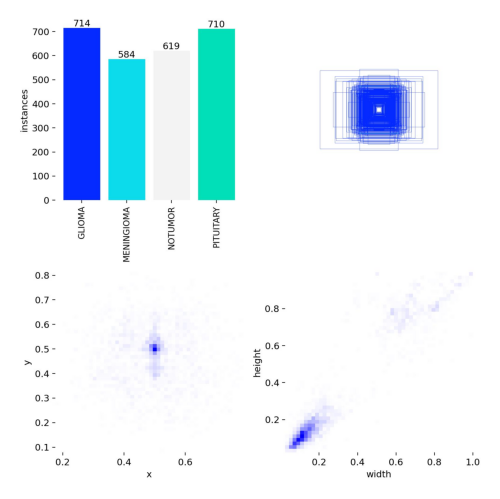

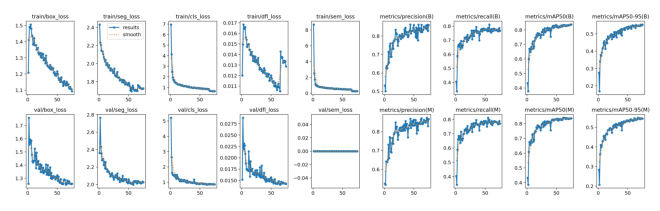

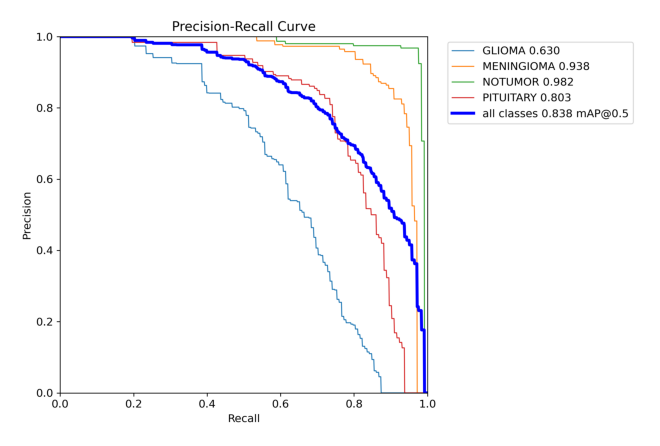

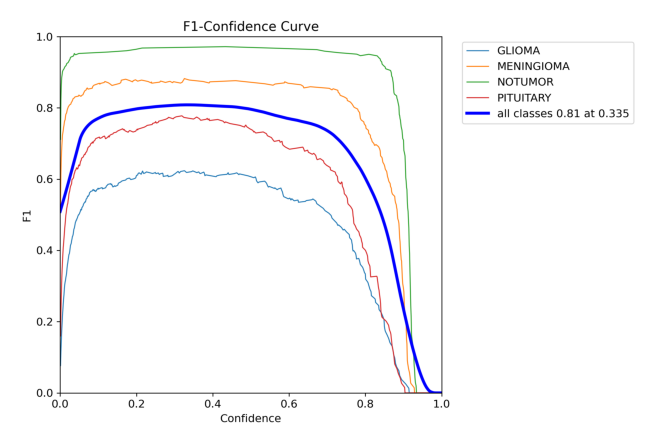

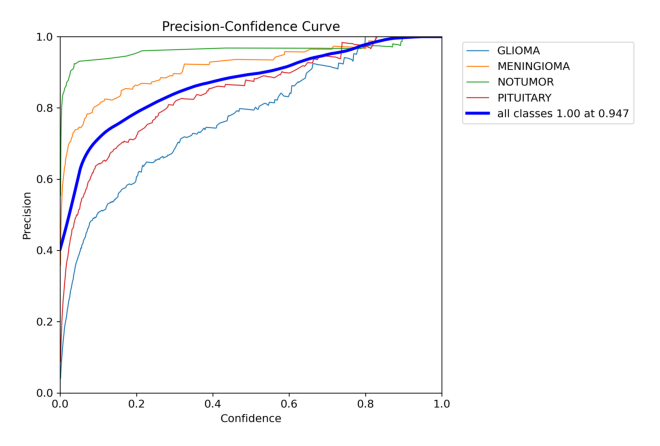

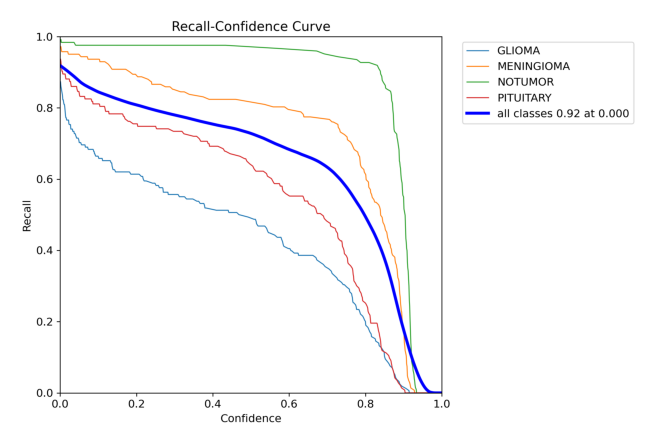

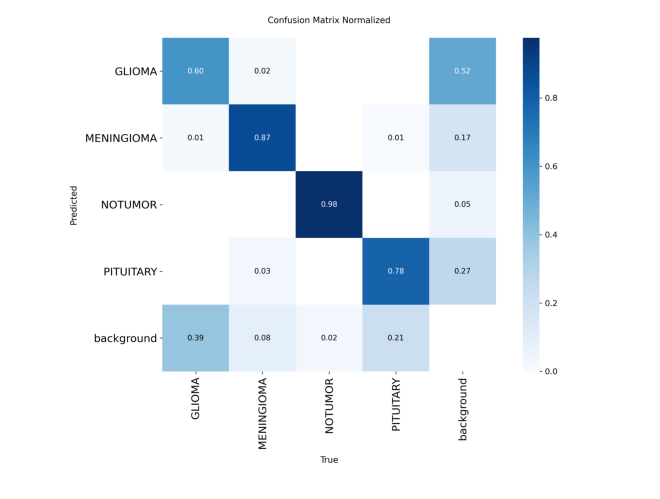

In [4]:
import sys
from pathlib import Path
import yaml
from ultralytics import YOLO

DATA_YAML = Path("data") / "mri_segmentation" / "data.yaml"
CONFIG_FILE = Path("config.yaml")

def train_mri() -> None:
    if not CONFIG_FILE.exists():
        print(f"Ошибка: Файл {CONFIG_FILE} не найден!")
        return

    cfg = yaml.safe_load(CONFIG_FILE.read_text())

    no_clearml = cfg.get("no_clearml", False)

    if not no_clearml:
        task = init_task(
            project=cfg["clearml_project"],
            name=cfg["clearml_task"],
            tags=["yolo11-seg", "mri", "segmentation"],
            config=cfg,
        )

    model_path = cfg.get("resume") if cfg.get("resume") else cfg["model"]
    model = YOLO(model_path)

    results = model.train(
        data=str(DATA_YAML),
        task="segment",
        epochs=cfg["epochs"],
        imgsz=cfg["imgsz"],
        batch=cfg["batch"],
        lr0=cfg["lr0"],
        lrf=cfg["lrf"],
        momentum=cfg["momentum"],
        weight_decay=cfg["weight_decay"],
        warmup_epochs=cfg["warmup_epochs"],
        patience=cfg["patience"],
        dropout=cfg["dropout"],
        hsv_h=cfg["hsv_h"],
        hsv_s=cfg["hsv_s"],
        hsv_v=cfg["hsv_v"],
        degrees=cfg["degrees"],
        translate=cfg["translate"],
        scale=cfg["scale"],
        flipud=cfg["flipud"],
        fliplr=cfg["fliplr"],
        mosaic=cfg["mosaic"],
        copy_paste=cfg["copy_paste"],
        project=str(cfg["project"]),
        name=cfg["name"],
        save=True,
        save_period=cfg["save_period"],
        resume=bool(cfg.get("resume")),
        device=0,
        plots=True,
        verbose=True,
    )

    best = Path(results.save_dir) / "weights" / "best.pt"
    print(f"\nBest model: {best}")

    if not no_clearml:
        upload_model(task, best, "mri-seg-best")
        task.close()

train_mri()